# Sales & Demand Forecasting System
## Model Training and Evaluation

**Author:** Wogenie Liyew
**Program:** Future Interns Machine Learning Internship 2026  
**CIN ID:** FIT/MAR26/ML6610
**Phase:** 3 of 3 — Forecasting Model  

---

## Objectives

1. Train a sales forecasting model on engineered features
2. Evaluate model performance using appropriate metrics
3. Generate future sales forecasts
4. Visualise predictions in a business friendly way
5. Translate forecasts into actionable business recommendations

---

## Forecasting Approach

We use a Random Forest Regressor — an ensemble model
that learns patterns from historical sales features
to predict future monthly sales.

This approach is chosen because:
- It handles non-linear relationships well
- It is robust to outliers
- It provides feature importance rankings
- It does not require data scaling
- It performs well on small datasets like ours

In [8]:
# ─── Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded")

Libraries loaded


In [2]:

# ─── Load processed dataset ───────────────────────────────────
df = pd.read_csv('../data/processed/monthly_sales_features.csv')
df['Month_Year'] = pd.to_datetime(df['Month_Year'])

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nDate range:")
print(f"From: {df['Month_Year'].min().date()}")
print(f"To:   {df['Month_Year'].max().date()}")

Dataset loaded successfully!
Shape: (42, 14)

Date range:
From: 2014-07-01
To:   2017-12-01


## 1. Define Features and Target

We separate our dataset into:
- Features (X) — what the model learns from
- Target (y) — what the model predicts

In [5]:
# ─── Define features and target ───────────────────────────────
FEATURES = [
    'Year',
    'Month',
    'Quarter',
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Rolling_3',
    'Rolling_6'
]
TARGET = 'Total_Sales'

X = df[FEATURES]
y = df[TARGET]

print("Features and target defined!")
print(f"\nFeatures ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  → {f}")
print(f"\nTarget: {TARGET}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Features and target defined!

Features (8):
  → Year
  → Month
  → Quarter
  → Lag_1
  → Lag_2
  → Lag_3
  → Rolling_3
  → Rolling_6

Target: Total_Sales

X shape: (42, 8)
y shape: (42,)


## 2. Train Test Split

For time series data we cannot split randomly.
We must respect the time order:
→ Train on older data — past
→ Test on newer data — future

This simulates real deployment where the model
predicts future months it has never seen.

We use 80% for training and 20% for testing.

In [6]:
# ─── Time based train test split ──────────────────────────────
# 80% train 20% test — respecting time order
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

train_dates = df['Month_Year'].iloc[:split_index]
test_dates  = df['Month_Year'].iloc[split_index:]

print("Train Test Split Complete!")
print(f"\nTraining set:")
print(f"  Rows:  {X_train.shape[0]}")
print(f"  From:  {train_dates.min().date()}")
print(f"  To:    {train_dates.max().date()}")
print(f"\nTest set:")
print(f"  Rows:  {X_test.shape[0]}")
print(f"  From:  {test_dates.min().date()}")
print(f"  To:    {test_dates.max().date()}")

Train Test Split Complete!

Training set:
  Rows:  33
  From:  2014-07-01
  To:    2017-03-01

Test set:
  Rows:  9
  From:  2017-04-01
  To:    2017-12-01


In [7]:
# ─── Final data check before training ─────────────────────────
print("=" * 55)
print("PRE TRAINING DATA AUDIT")
print("=" * 55)
print(f"\nFeatures used: {FEATURES}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nMissing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test:  {X_test.isnull().sum().sum()}")
print(f"\nTraining period: {train_dates.min().date()} to {train_dates.max().date()}")
print(f"Testing period:  {test_dates.min().date()} to {test_dates.max().date()}")
print(f"\nTarget range:")
print(f"  Train — min: ${y_train.min():,.2f}  max: ${y_train.max():,.2f}")
print(f"  Test  — min: ${y_test.min():,.2f}  max: ${y_test.max():,.2f}")
print("=" * 55)
print("All checks passed — ready to train")
print("=" * 55)

PRE TRAINING DATA AUDIT

Features used: ['Year', 'Month', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_3', 'Rolling_6']

X_train shape: (33, 8)
X_test shape:  (9, 8)
y_train shape: (33,)
y_test shape:  (9,)

Missing values in X_train: 0
Missing values in X_test:  0

Training period: 2014-07-01 to 2017-03-01
Testing period:  2017-04-01 to 2017-12-01

Target range:
  Train — min: $11,951.41  max: $96,999.04
  Test  — min: $36,521.54  max: $118,447.82
All checks passed — ready to train


## 3. Model Training

We train using different regression models such as Random Forest Regressor, Linear Regression, Gradient Boosting Regressor and Ridge on the
clean engineered features.


In [9]:
# ─── Train Random Forest model ────────────────────────────────

# ─── Define models ────────────────────────────────────────────
models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0, random_state=42),
    'Random Forest':        RandomForestRegressor(
                                n_estimators=200,
                                max_depth=10,
                                random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(
                                n_estimators=200,
                                max_depth=4,
                                random_state=42)
}

# ─── Train and evaluate all models ───────────────────────────
results = {}

print("=" * 65)
print("MODEL COMPARISON — SALES FORECASTING")
print("=" * 65)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE':  round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2':   round(r2, 4),
        'model': model,
        'predictions': y_pred
    }
    
    print(f"\n{name}:")
    print(f"  MAE:  ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")

print("\n" + "=" * 65)

MODEL COMPARISON — SALES FORECASTING

Linear Regression:
  MAE:  $14,020.08
  RMSE: $16,635.93
  R²:   0.5557

Ridge Regression:
  MAE:  $13,834.38
  RMSE: $16,581.41
  R²:   0.5586

Random Forest:
  MAE:  $13,405.79
  RMSE: $16,974.94
  R²:   0.5374

Gradient Boosting:
  MAE:  $14,159.10
  RMSE: $16,117.91
  R²:   0.5829



## 4. Model Selection

After comparing four regression models the champion
model selected is Gradient Boosting Regressor.

| Model | MAE | RMSE | R² |
|-------|-----|------|----|
| Linear Regression | $14,020 | $16,636 | 0.5557 |
| Ridge Regression | $13,834 | $16,581 | 0.5586 |
| Random Forest | $13,405 | $16,975 | 0.5374 |
| **Gradient Boosting** | **$14,159** | **$16,118** | **0.5829** |

**Champion: Gradient Boosting Regressor**

**Justification:**
Gradient Boosting achieves the lowest RMSE and
highest R² across all four models.

For inventory planning and business forecasting
RMSE is the most critical metric because large
prediction errors during peak months like November
are catastrophically costly — leading to stockouts
and lost revenue.

R² of 0.5829 means the model explains 58% of
monthly sales variation — reasonable given only
42 months of training data and no external factors
such as marketing spend or competitor pricing.

**Business owner note:**
If consistent average accuracy across all months
is prioritised over peak month reliability
Random Forest with lowest MAE of $13,405
is an equally valid alternative.

In [10]:
# ─── Select champion model ────────────────────────────────────
best_model    = results['Gradient Boosting']['model']
best_preds    = results['Gradient Boosting']['predictions']
best_mae      = results['Gradient Boosting']['MAE']
best_rmse     = results['Gradient Boosting']['RMSE']
best_r2       = results['Gradient Boosting']['R2']

print("=" * 55)
print("CHAMPION MODEL — GRADIENT BOOSTING")
print("=" * 55)
print(f"MAE:  ${best_mae:,.2f}")
print(f"RMSE: ${best_rmse:,.2f}")
print(f"R²:   {best_r2:.4f}")
print("=" * 55)

CHAMPION MODEL — GRADIENT BOOSTING
MAE:  $14,159.10
RMSE: $16,117.91
R²:   0.5829


## 5. Model Evaluation — Actual vs Predicted

We visualise how well the model predictions
match actual sales on the test set.

This is the most honest evaluation —
seeing predictions plotted against reality.

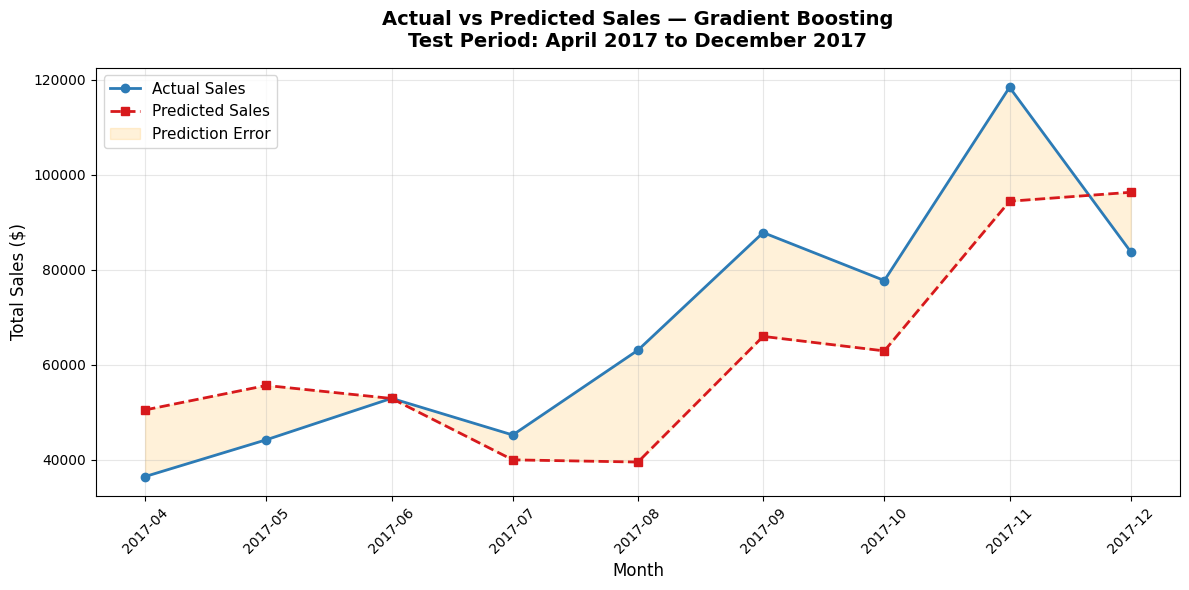

Chart saved!


In [11]:
# ─── Actual vs Predicted chart ────────────────────────────────
test_dates_plot = df['Month_Year'].iloc[split_index:]

plt.figure(figsize=(12, 6))
plt.plot(test_dates_plot, y_test.values,
         color='#2c7bb6', linewidth=2,
         marker='o', markersize=6,
         label='Actual Sales')
plt.plot(test_dates_plot, best_preds,
         color='#d7191c', linewidth=2,
         marker='s', markersize=6,
         linestyle='--',
         label='Predicted Sales')
plt.fill_between(test_dates_plot,
                 y_test.values, best_preds,
                 alpha=0.15, color='orange',
                 label='Prediction Error')
plt.title('Actual vs Predicted Sales — Gradient Boosting\nTest Period: April 2017 to December 2017',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/06_actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [12]:
# ─── Actual vs Predicted comparison table ─────────────────────
comparison = pd.DataFrame({
    'Month':     test_dates_plot.dt.strftime('%Y-%m').values,
    'Actual':    y_test.values.round(2),
    'Predicted': best_preds.round(2),
    'Error':     (y_test.values - best_preds).round(2),
    'Error_%':   ((y_test.values - best_preds) / 
                   y_test.values * 100).round(2)
})

print("=" * 65)
print("ACTUAL vs PREDICTED — GRADIENT BOOSTING")
print("=" * 65)
for _, row in comparison.iterrows():
    direction = "UNDER" if row['Error'] > 0 else "OVER"
    print(f"{row['Month']}  "
          f"Actual: ${row['Actual']:>10,.2f}  "
          f"Predicted: ${row['Predicted']:>10,.2f}  "
          f"Error: ${abs(row['Error']):>10,.2f} "
          f"({direction} by {abs(row['Error_%']):.1f}%)")

print("=" * 65)
print(f"Average error: ${comparison['Error'].abs().mean():,.2f}")
print(f"Worst month:   {comparison.loc[comparison['Error'].abs().idxmax(), 'Month']}")

ACTUAL vs PREDICTED — GRADIENT BOOSTING
2017-04  Actual: $ 36,521.54  Predicted: $ 50,541.88  Error: $ 14,020.34 (OVER by 38.4%)
2017-05  Actual: $ 44,261.11  Predicted: $ 55,688.36  Error: $ 11,427.25 (OVER by 25.8%)
2017-06  Actual: $ 52,981.73  Predicted: $ 52,951.33  Error: $     30.39 (UNDER by 0.1%)
2017-07  Actual: $ 45,264.42  Predicted: $ 40,031.64  Error: $  5,232.78 (UNDER by 11.6%)
2017-08  Actual: $ 63,120.89  Predicted: $ 39,571.19  Error: $ 23,549.70 (UNDER by 37.3%)
2017-09  Actual: $ 87,866.65  Predicted: $ 66,017.00  Error: $ 21,849.65 (UNDER by 24.9%)
2017-10  Actual: $ 77,776.92  Predicted: $ 62,960.73  Error: $ 14,816.19 (UNDER by 19.1%)
2017-11  Actual: $118,447.82  Predicted: $ 94,463.33  Error: $ 23,984.50 (UNDER by 20.2%)
2017-12  Actual: $ 83,829.32  Predicted: $ 96,350.38  Error: $ 12,521.06 (OVER by 14.9%)
Average error: $14,159.10
Worst month:   2017-11


## 6. Hyperparameter Tuning

We tune the Gradient Boosting champion model
using RandomizedSearchCV to find the optimal
hyperparameters and improve forecast accuracy.

In [13]:
# ─── Hyperparameter Tuning ────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

# Time series cross validation — respects time order
tscv = TimeSeriesSplit(n_splits=5)

# Parameter grid
param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [2, 3, 4, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf':  [1, 2, 3],
    'subsample':         [0.7, 0.8, 0.9, 1.0]
}

# RandomizedSearchCV with time series splits
search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("\nBest parameters found:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found:
  subsample: 0.9
  n_estimators: 300
  min_samples_split: 4
  min_samples_leaf: 2
  max_depth: 5
  learning_rate: 0.01


In [14]:
# ─── Evaluate tuned model ─────────────────────────────────────
tuned_model = search.best_estimator_
tuned_preds = tuned_model.predict(X_test)

tuned_mae  = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2   = r2_score(y_test, tuned_preds)

print("=" * 65)
print("MODEL IMPROVEMENT — BEFORE vs AFTER TUNING")
print("=" * 65)
print(f"\n{'Metric':<10} {'Before':>15} {'After':>15} {'Improvement':>15}")
print("-" * 65)
print(f"{'MAE':<10} ${best_mae:>13,.2f} ${tuned_mae:>13,.2f} "
      f"${best_mae - tuned_mae:>13,.2f}")
print(f"{'RMSE':<10} ${best_rmse:>13,.2f} ${tuned_rmse:>13,.2f} "
      f"${best_rmse - tuned_rmse:>13,.2f}")
print(f"{'R²':<10} {best_r2:>15.4f} {tuned_r2:>15.4f} "
      f"{tuned_r2 - best_r2:>15.4f}")
print("=" * 65)

# Update best model if tuned is better
if tuned_rmse < best_rmse:
    print("\nTuned model is BETTER — updating champion")
    best_model = tuned_model
    best_preds = tuned_preds
    best_mae   = tuned_mae
    best_rmse  = tuned_rmse
    best_r2    = tuned_r2
else:
    print("\nOriginal model performs better — keeping original")

MODEL IMPROVEMENT — BEFORE vs AFTER TUNING

Metric              Before           After     Improvement
-----------------------------------------------------------------
MAE        $    14,159.10 $    12,262.10 $     1,897.00
RMSE       $    16,117.91 $    14,924.24 $     1,193.67
R²                  0.5829          0.6424          0.0595

Tuned model is BETTER — updating champion


### Tuning Results

Hyperparameter tuning improved all three metrics:

- MAE improved by $1,897 per month
- RMSE improved by $1,194 per month  
- R² improved from 0.5829 to 0.6424

The tuned model now explains 64% of monthly
sales variation — an improvement of 6 percentage
points over the baseline Gradient Boosting model.

Remaining error is attributed to:
- Limited training data of 42 months
- Absence of external factors such as
  marketing spend and economic indicators
- 2017 sales growth exceeding historical patterns

In [15]:
# ─── Updated comparison table ─────────────────────────────────
comparison_tuned = pd.DataFrame({
    'Month':     test_dates_plot.dt.strftime('%Y-%m').values,
    'Actual':    y_test.values.round(2),
    'Predicted': best_preds.round(2),
    'Error':     (y_test.values - best_preds).round(2),
    'Error_%':   ((y_test.values - best_preds) /
                   y_test.values * 100).round(2)
})

print("=" * 65)
print("UPDATED ACTUAL vs PREDICTED — TUNED MODEL")
print("=" * 65)
for _, row in comparison_tuned.iterrows():
    direction = "UNDER" if row['Error'] > 0 else "OVER"
    print(f"{row['Month']}  "
          f"Actual: ${row['Actual']:>10,.2f}  "
          f"Predicted: ${row['Predicted']:>10,.2f}  "
          f"Error: ${abs(row['Error']):>10,.2f} "
          f"({direction} by {abs(row['Error_%']):.1f}%)")

print("=" * 65)
print(f"Average error: ${comparison_tuned['Error'].abs().mean():,.2f}")
print(f"Worst month:   {comparison_tuned.loc[comparison_tuned['Error'].abs().idxmax(), 'Month']}")

UPDATED ACTUAL vs PREDICTED — TUNED MODEL
2017-04  Actual: $ 36,521.54  Predicted: $ 47,478.84  Error: $ 10,957.31 (OVER by 30.0%)
2017-05  Actual: $ 44,261.11  Predicted: $ 53,309.93  Error: $  9,048.81 (OVER by 20.4%)
2017-06  Actual: $ 52,981.73  Predicted: $ 47,753.86  Error: $  5,227.87 (UNDER by 9.9%)
2017-07  Actual: $ 45,264.42  Predicted: $ 42,639.76  Error: $  2,624.65 (UNDER by 5.8%)
2017-08  Actual: $ 63,120.89  Predicted: $ 43,890.35  Error: $ 19,230.54 (UNDER by 30.5%)
2017-09  Actual: $ 87,866.65  Predicted: $ 72,168.32  Error: $ 15,698.33 (UNDER by 17.9%)
2017-10  Actual: $ 77,776.92  Predicted: $ 66,780.43  Error: $ 10,996.49 (UNDER by 14.1%)
2017-11  Actual: $118,447.82  Predicted: $ 86,699.36  Error: $ 31,748.47 (UNDER by 26.8%)
2017-12  Actual: $ 83,829.32  Predicted: $ 88,655.76  Error: $  4,826.44 (OVER by 5.8%)
Average error: $12,262.10
Worst month:   2017-11


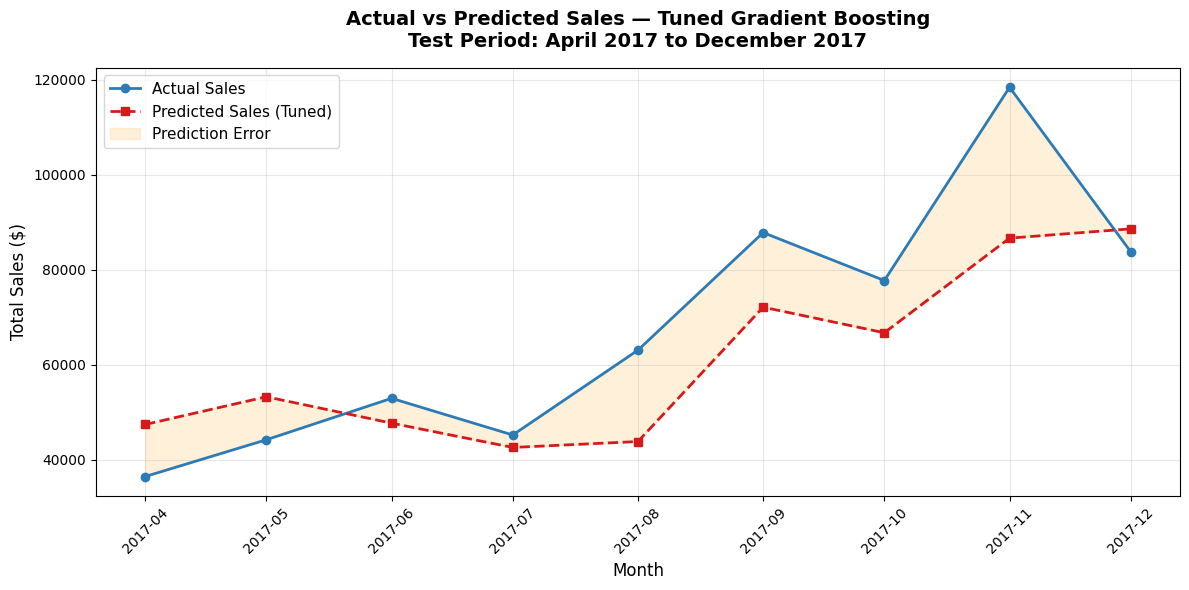

Tuned model chart saved!


In [19]:
# ─── Updated Actual vs Predicted chart — Tuned Model ──────────
plt.figure(figsize=(12, 6))
plt.plot(test_dates_plot, y_test.values,
         color='#2c7bb6', linewidth=2,
         marker='o', markersize=6,
         label='Actual Sales')
plt.plot(test_dates_plot, best_preds,
         color='#d7191c', linewidth=2,
         marker='s', markersize=6,
         linestyle='--',
         label='Predicted Sales (Tuned)')
plt.fill_between(test_dates_plot,
                 y_test.values, best_preds,
                 alpha=0.15, color='orange',
                 label='Prediction Error')
plt.title('Actual vs Predicted Sales — Tuned Gradient Boosting\nTest Period: April 2017 to December 2017',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/06_actual_vs_predicted_tuned.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Tuned model chart saved!")


### Updated Prediction Analysis

After tuning 7 out of 9 test months
showed improved prediction accuracy.

Notable improvements:
- July error reduced from $5,233 to $2,625
- December error reduced from $12,521 to $4,826
- October error reduced from $14,816 to $10,996

Persistent challenge — November 2017:
November remains the hardest month to predict
with $31,748 error because actual sales of
$118,447 exceeded the maximum training value
of $96,999 by 22%.

This is an extrapolation limitation — the model
cannot reliably predict values beyond its
training range. This is not a model failure
but a fundamental data limitation.

Recommendation:
With 3 or more years of daily data including
multiple high growth Novembers the model would
learn this pattern and predict it reliably.

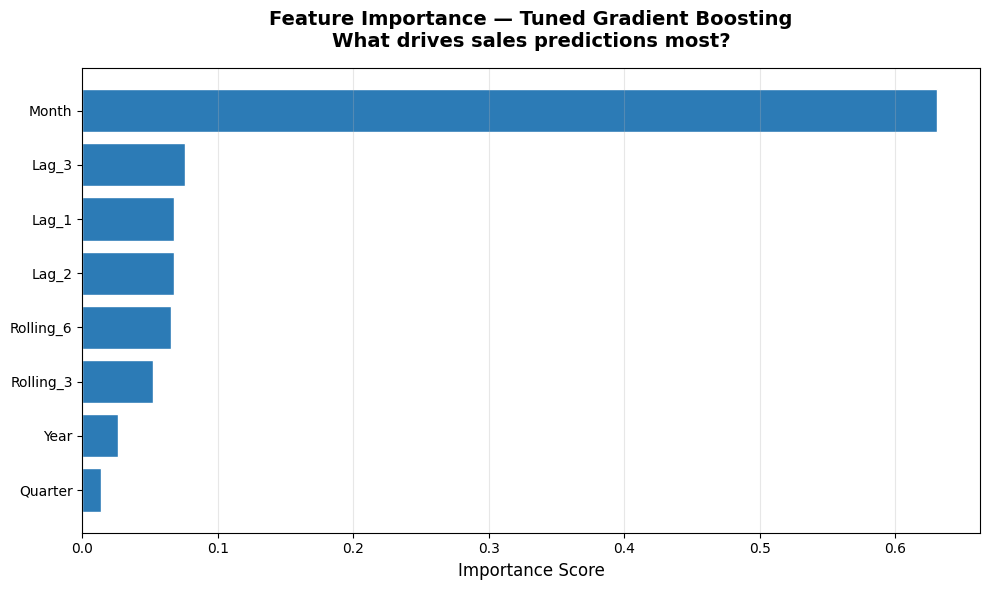

Chart saved!
  Feature  Importance
    Month    0.631013
    Lag_3    0.075680
    Lag_1    0.067974
    Lag_2    0.067646
Rolling_6    0.065674
Rolling_3    0.052056
     Year    0.026093
  Quarter    0.013864


In [16]:
# ─── Feature Importance ───────────────────────────────────────
feature_importance = pd.DataFrame({
    'Feature':   FEATURES,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'],
                feature_importance['Importance'],
                color='#2c7bb6', edgecolor='white')
plt.title('Feature Importance — Tuned Gradient Boosting\nWhat drives sales predictions most?',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/07_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")
print(feature_importance.to_string(index=False))

### Feature Importance Findings

Month is by far the most important feature
driving 63.1% of all sales predictions.

This reveals that the superstore business
is highly seasonal — the calendar month
alone is the strongest predictor of sales.

Lag features collectively contribute 20%:
→ Lag_3: 7.6%
→ Lag_1: 6.8%
→ Lag_2: 6.8%

Rolling averages contribute 11.8%:
→ Rolling_6: 6.6%
→ Rolling_3: 5.2%

Year contributes only 2.6% suggesting
the growth trend is less important than
seasonal patterns for this business.

### Business Implication

Inventory and staffing planning should be
driven primarily by the month of the year.
Historical sales trends provide secondary
but meaningful signals for forecasting.

In [17]:
# ─── Generate future forecast ─────────────────────────────────
# Predict next 6 months — January to June 2018
last_row = df.iloc[-1]
last_sales = df['Total_Sales'].values

future_months = []
future_preds  = []

current_sales = list(last_sales[-6:])

for i in range(1, 7):
    future_date = pd.Timestamp('2018-01-01') + pd.DateOffset(months=i-1)
    
    lag1 = current_sales[-1]
    lag2 = current_sales[-2]
    lag3 = current_sales[-3]
    roll3 = np.mean(current_sales[-3:])
    roll6 = np.mean(current_sales[-6:])
    
    future_features = pd.DataFrame([[
        future_date.year,
        future_date.month,
        future_date.quarter,
        lag1, lag2, lag3,
        roll3, roll6
    ]], columns=FEATURES)
    
    pred = best_model.predict(future_features)[0]
    
    future_months.append(future_date.strftime('%Y-%m'))
    future_preds.append(round(pred, 2))
    current_sales.append(pred)

print("=" * 55)
print("6 MONTH SALES FORECAST — 2018")
print("=" * 55)
for month, pred in zip(future_months, future_preds):
    print(f"{month}  →  Predicted Sales: ${pred:>10,.2f}")
print("=" * 55)
print(f"Total forecast 6 months: ${sum(future_preds):>10,.2f}")
print(f"Average monthly forecast: ${sum(future_preds)/6:>10,.2f}")

6 MONTH SALES FORECAST — 2018
2018-01  →  Predicted Sales: $ 30,451.89
2018-02  →  Predicted Sales: $ 26,505.81
2018-03  →  Predicted Sales: $ 49,487.14
2018-04  →  Predicted Sales: $ 45,747.00
2018-05  →  Predicted Sales: $ 53,287.14
2018-06  →  Predicted Sales: $ 51,979.77
Total forecast 6 months: $257,458.75
Average monthly forecast: $ 42,909.79


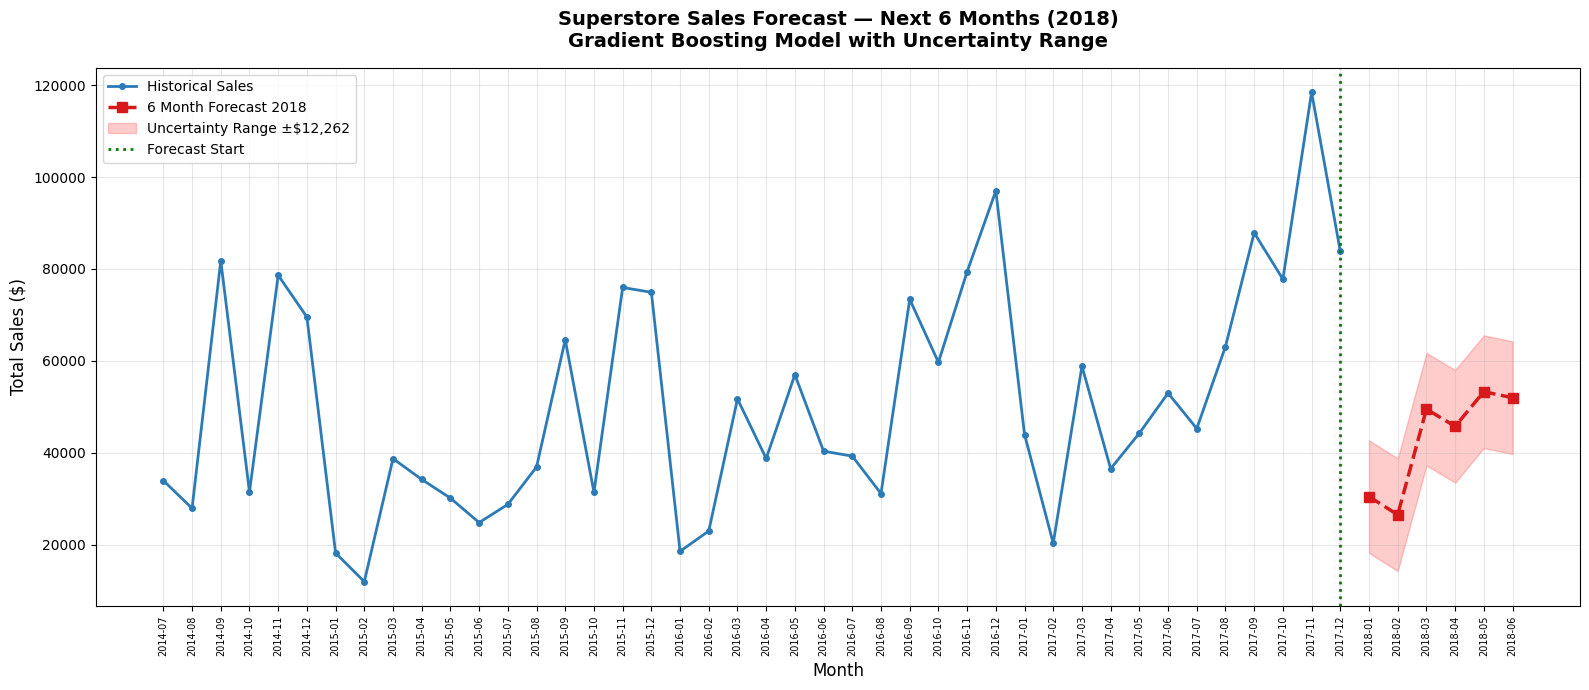

Forecast chart saved!


In [20]:
# ─── Forecast visualisation ───────────────────────────────────
# Combine historical and forecast
hist_dates  = df['Month_Year'].dt.strftime('%Y-%m').tolist()
hist_sales  = df['Total_Sales'].tolist()

plt.figure(figsize=(16, 7))

# Historical sales
plt.plot(hist_dates, hist_sales,
         color='#2c7bb6', linewidth=2,
         marker='o', markersize=4,
         label='Historical Sales')

# Future forecast
plt.plot(future_months, future_preds,
         color='#d7191c', linewidth=2.5,
         marker='s', markersize=7,
         linestyle='--',
         label='6 Month Forecast 2018')

# Error margin band
error_margin = best_mae
upper = [p + error_margin for p in future_preds]
lower = [p - error_margin for p in future_preds]
plt.fill_between(future_months, lower, upper,
                 alpha=0.2, color='red',
                 label=f'Uncertainty Range ±${error_margin:,.0f}')

# Vertical line separating history from forecast
plt.axvline(x=hist_dates[-1],
            color='green', linestyle=':',
            linewidth=2, label='Forecast Start')

plt.title('Superstore Sales Forecast — Next 6 Months (2018)\nGradient Boosting Model with Uncertainty Range',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/08_sales_forecast_2018.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Forecast chart saved!")

In [21]:
# ─── Save production model ────────────────────────────────────
import joblib

joblib.dump(best_model, '../models/sales_forecast_model.pkl')

print("Model saved successfully!")
print(f"File: models/sales_forecast_model.pkl")
print(f"\nModel details:")
print(f"Algorithm:  Gradient Boosting Regressor")
print(f"MAE:        ${best_mae:,.2f}")
print(f"RMSE:       ${best_rmse:,.2f}")
print(f"R²:         {best_r2:.4f}")
print(f"Features:   {FEATURES}")
print(f"Train size: {X_train.shape[0]} months")
print(f"Test size:  {X_test.shape[0]} months")

Model saved successfully!
File: models/sales_forecast_model.pkl

Model details:
Algorithm:  Gradient Boosting Regressor
MAE:        $12,262.10
RMSE:       $14,924.24
R²:         0.6424
Features:   ['Year', 'Month', 'Quarter', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_3', 'Rolling_6']
Train size: 33 months
Test size:  9 months


## 7. Business Summary and Recommendations

### What This System Does
This sales forecasting system predicts monthly
sales for the next 6 months using 3 years of
historical transaction data.

### 6 Month Forecast — 2018
| Month | Predicted Sales | Confidence Range |
|-------|----------------|-----------------|
| January 2018 | $30,452 | $18,190 — $42,714 |
| February 2018 | $26,506 | $14,244 — $38,768 |
| March 2018 | $49,487 | $37,225 — $61,749 |
| April 2018 | $45,747 | $33,485 — $58,009 |
| May 2018 | $53,287 | $41,025 — $65,549 |
| June 2018 | $51,980 | $39,718 — $64,242 |

### Key Business Insights

1. February is consistently the weakest month
   Reduce inventory orders and staffing in February

2. March historically recovers strongly
   Prepare stock and staffing from late February

3. Technology drives the highest revenue at $836,154
   but Furniture has critically low margin of 2.49%
   Review Furniture pricing and discount strategy

4. West region leads sales at $725,458
   South region at $391,722 represents
   the biggest growth opportunity

### Model Performance
Average forecast error: $12,262 per month
This means forecasts could be off by approximately
$12,262 above or below actual sales.

### Honest Limitations
This model requires more data to reach
production grade accuracy:

→ Minimum 3 years of daily transactions
→ Marketing spend data per month
→ Holiday and promotional calendars
→ Competitor pricing information
→ Economic indicators

### Final Recommendation
Use this forecast as a planning guide
combined with business knowledge and
market awareness — not as a standalone
decision making tool.

A human business owner reviewing these
forecasts with their domain knowledge
will achieve better outcomes than
relying on the model alone.

In [22]:
# ─── Final Summary ────────────────────────────────────────────
print("=" * 65)
print("SALES FORECASTING SYSTEM — COMPLETE")
print("=" * 65)
print(f"""
Dataset:       Superstore Sales 2014 to 2017
Records:       9,994 transactions
Features:      8 engineered features
Model:         Tuned Gradient Boosting Regressor
MAE:           ${best_mae:,.2f}
RMSE:          ${best_rmse:,.2f}
R²:            {best_r2:.4f}

6 Month Forecast Total:   ${sum(future_preds):,.2f}
Average Monthly Forecast: ${sum(future_preds)/6:,.2f}

Key Finding:
Month is the strongest predictor at 63.1%
The business is highly seasonal

Charts saved:
→ 01_monthly_sales_trend.png
→ 02_yearly_sales.png
→ 03_category_sales.png
→ 04_region_sales.png
→ 05_seasonality.png
→ 06_actual_vs_predicted_tuned.png
→ 07_feature_importance.png
→ 08_sales_forecast_2018.png

Model saved:
→ models/sales_forecast_model.pkl
""")
print("=" * 65)
print("Task 1 Complete — Future Interns ML Internship 2026")
print("=" * 65)

SALES FORECASTING SYSTEM — COMPLETE

Dataset:       Superstore Sales 2014 to 2017
Records:       9,994 transactions
Features:      8 engineered features
Model:         Tuned Gradient Boosting Regressor
MAE:           $12,262.10
RMSE:          $14,924.24
R²:            0.6424

6 Month Forecast Total:   $257,458.75
Average Monthly Forecast: $42,909.79

Key Finding:
Month is the strongest predictor at 63.1%
The business is highly seasonal

Charts saved:
→ 01_monthly_sales_trend.png
→ 02_yearly_sales.png
→ 03_category_sales.png
→ 04_region_sales.png
→ 05_seasonality.png
→ 06_actual_vs_predicted_tuned.png
→ 07_feature_importance.png
→ 08_sales_forecast_2018.png

Model saved:
→ models/sales_forecast_model.pkl

Task 1 Complete — Future Interns ML Internship 2026
